In [36]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## [European Soccer Database](https://www.kaggle.com/datasets/hugomathien/soccer)

25k+ matches, players & teams attributes for European Professional Football

Loading the data

In [37]:
import sqlite3

path = 'european_soccer.sqlite' # download databse from kaggle link
con = sqlite3.connect(path)

# get the list of tables in the database
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", con)

# see the structure of each table
for table in tables['name'][1:]:
    structure = pd.read_sql_query(f"PRAGMA table_info({table});", con)
    print(f"Table: {table}")
    print(structure)
    print("\n")

Table: Player_Attributes
    cid                 name     type  notnull dflt_value  pk
0     0                   id  INTEGER        0       None   1
1     1   player_fifa_api_id  INTEGER        0       None   0
2     2        player_api_id  INTEGER        0       None   0
3     3                 date     TEXT        0       None   0
4     4       overall_rating  INTEGER        0       None   0
5     5            potential  INTEGER        0       None   0
6     6       preferred_foot     TEXT        0       None   0
7     7  attacking_work_rate     TEXT        0       None   0
8     8  defensive_work_rate     TEXT        0       None   0
9     9             crossing  INTEGER        0       None   0
10   10            finishing  INTEGER        0       None   0
11   11     heading_accuracy  INTEGER        0       None   0
12   12        short_passing  INTEGER        0       None   0
13   13              volleys  INTEGER        0       None   0
14   14            dribbling  INTEGER        

In [38]:
countries = pd.read_sql_query("SELECT * FROM Country;", con)
print(countries.head())

      id     name
0      1  Belgium
1   1729  England
2   4769   France
3   7809  Germany
4  10257    Italy


In [39]:
leagues = pd.read_sql_query("SELECT * FROM League;", con)
print(leagues.head())

      id  country_id                    name
0      1           1  Belgium Jupiler League
1   1729        1729  England Premier League
2   4769        4769          France Ligue 1
3   7809        7809   Germany 1. Bundesliga
4  10257       10257           Italy Serie A


In [40]:
matches = pd.read_sql_query("SELECT * FROM Match;", con)
print(matches.head())

   id  country_id  league_id     season  stage                 date  \
0   1           1          1  2008/2009      1  2008-08-17 00:00:00   
1   2           1          1  2008/2009      1  2008-08-16 00:00:00   
2   3           1          1  2008/2009      1  2008-08-16 00:00:00   
3   4           1          1  2008/2009      1  2008-08-17 00:00:00   
4   5           1          1  2008/2009      1  2008-08-16 00:00:00   

   match_api_id  home_team_api_id  away_team_api_id  home_team_goal  ...  \
0        492473              9987              9993               1  ...   
1        492474             10000              9994               0  ...   
2        492475              9984              8635               0  ...   
3        492476              9991              9998               5  ...   
4        492477              7947              9985               1  ...   

    SJA   VCH   VCD   VCA   GBH   GBD   GBA   BSH   BSD   BSA  
0  4.00  1.65  3.40  4.50  1.78  3.25  4.00  1.73  3

In [41]:
players = pd.read_sql_query("SELECT * FROM Player;", con)
print(players.head())

   id  player_api_id         player_name  player_fifa_api_id  \
0   1         505942  Aaron Appindangoye              218353   
1   2         155782     Aaron Cresswell              189615   
2   3         162549         Aaron Doran              186170   
3   4          30572       Aaron Galindo              140161   
4   5          23780        Aaron Hughes               17725   

              birthday  height  weight  
0  1992-02-29 00:00:00  182.88     187  
1  1989-12-15 00:00:00  170.18     146  
2  1991-05-13 00:00:00  170.18     163  
3  1982-05-08 00:00:00  182.88     198  
4  1979-11-08 00:00:00  182.88     154  


In [42]:
players_attributes = pd.read_sql_query("SELECT * FROM Player_Attributes;", con)
print(players_attributes.head())

   id  player_fifa_api_id  player_api_id                 date  overall_rating  \
0   1              218353         505942  2016-02-18 00:00:00            67.0   
1   2              218353         505942  2015-11-19 00:00:00            67.0   
2   3              218353         505942  2015-09-21 00:00:00            62.0   
3   4              218353         505942  2015-03-20 00:00:00            61.0   
4   5              218353         505942  2007-02-22 00:00:00            61.0   

   potential preferred_foot attacking_work_rate defensive_work_rate  crossing  \
0       71.0          right              medium              medium      49.0   
1       71.0          right              medium              medium      49.0   
2       66.0          right              medium              medium      49.0   
3       65.0          right              medium              medium      48.0   
4       65.0          right              medium              medium      48.0   

   ...  vision  penalties 

In [43]:
teams = pd.read_sql_query("SELECT * FROM Team;", con)
print(teams.head())

   id  team_api_id  team_fifa_api_id     team_long_name team_short_name
0   1         9987             673.0           KRC Genk             GEN
1   2         9993             675.0       Beerschot AC             BAC
2   3        10000           15005.0   SV Zulte-Waregem             ZUL
3   4         9994            2007.0   Sporting Lokeren             LOK
4   5         9984            1750.0  KSV Cercle Brugge             CEB


In [44]:
teams_attributes = pd.read_sql_query("SELECT * FROM Team_Attributes;", con)
print(teams_attributes.head())

   id  team_fifa_api_id  team_api_id                 date  buildUpPlaySpeed  \
0   1               434         9930  2010-02-22 00:00:00                60   
1   2               434         9930  2014-09-19 00:00:00                52   
2   3               434         9930  2015-09-10 00:00:00                47   
3   4                77         8485  2010-02-22 00:00:00                70   
4   5                77         8485  2011-02-22 00:00:00                47   

  buildUpPlaySpeedClass  buildUpPlayDribbling buildUpPlayDribblingClass  \
0              Balanced                   NaN                    Little   
1              Balanced                  48.0                    Normal   
2              Balanced                  41.0                    Normal   
3                  Fast                   NaN                    Little   
4              Balanced                   NaN                    Little   

   buildUpPlayPassing buildUpPlayPassingClass  ... chanceCreationShooting 

Boxplot and histogram for the age of the players

In [46]:
print(players['birthday'][:5])

0    1992-02-29 00:00:00
1    1989-12-15 00:00:00
2    1991-05-13 00:00:00
3    1982-05-08 00:00:00
4    1979-11-08 00:00:00
Name: birthday, dtype: object


In [66]:
# get the age of each player from their birthday (the current date being 16th Oct 2016 according to kaggle)
def get_age(date: str) -> int:
    from datetime import datetime
    today = datetime.strptime('2016-10-16', '%Y-%m-%d')
    birth_date = datetime.strptime(date, '%Y-%m-%d %H:%M:%S')
    age = today.year - birth_date.year - ((today.month, today.day) < (birth_date.month, birth_date.day))
    return age

ages = players['birthday'].apply(get_age)
print(ages[:5])

0    24
1    26
2    25
3    34
4    36
Name: birthday, dtype: int64


Text(0.5, 1.0, 'Distribution of Player Ages')

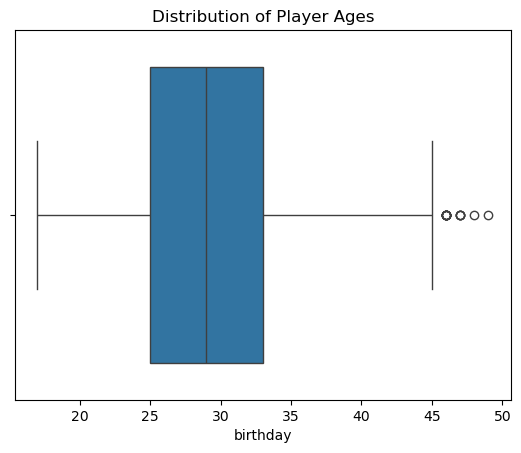

In [68]:
sns.boxplot(x=ages)
plt.title('Distribution of Player Ages')

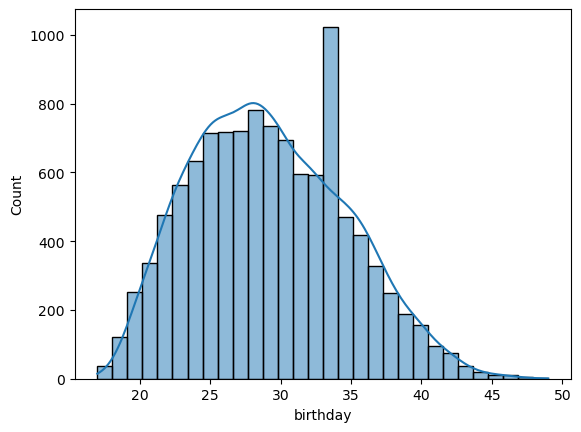

In [ ]:
sns.histplot(ages, bins=30, kde=True)
plt.show()
# we can see that there much more players in the age range of 33-34 years than any other age range

Is there any relation beetween the age and the acceleration of the players?

In [82]:
from datetime import datetime

df_birthday_acceleration = pd.read_sql_query(
    "SELECT birthday, acceleration " \
"FROM Player JOIN Player_Attributes " \
"ON Player.player_api_id = Player_Attributes.player_api_id"
, con)
df_birthday_acceleration['birthday'] = df_birthday_acceleration['birthday'].apply(datetime.strptime, args=('%Y-%m-%d %H:%M:%S',))
df_birthday_acceleration.head()

,birthday,acceleration
0,1992-02-29,60.0
1,1992-02-29,60.0
2,1992-02-29,60.0
3,1992-02-29,60.0
4,1992-02-29,60.0


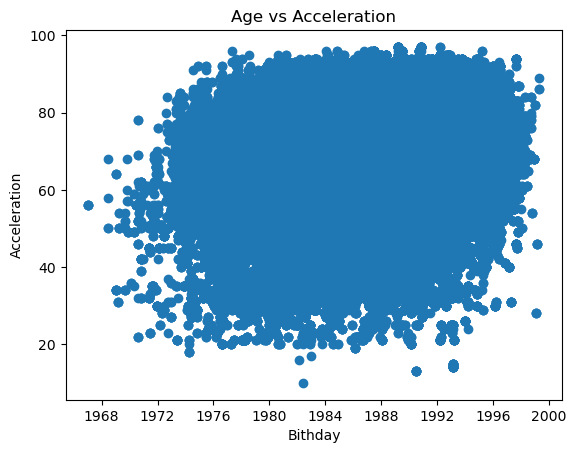

In [83]:
plt.scatter(df_birthday_acceleration['birthday'], df_birthday_acceleration['acceleration'])
plt.xlabel('Bithday')
plt.ylabel('Acceleration')
plt.title('Age vs Acceleration')
plt.show()

In [85]:
corr = df_birthday_acceleration['birthday'].apply(lambda x: x.toordinal()).corr(df_birthday_acceleration['acceleration'])
print(f"Correlation between birthday and acceleration: {corr}")
# We can see that there is almost no correlation between the age of a player and their acceleration attribute, 
# which is surprising as we would expect older players to have lower acceleration. 
# This could be due to the fact that the database contains players of different skill levels and positions.

Correlation between birthday and acceleration: 0.2400180331064841
